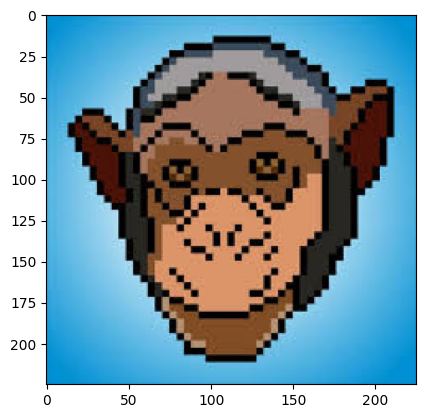

In [1]:
# %matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("images/scimmia.jpeg")

fig, ax = plt.subplots()
ax.imshow(img)

def onclick(event):
    if event.xdata is not None and event.ydata is not None:
        x, y = int(event.xdata), int(event.ydata)
        ax.plot(x, y, 'ro')  # red dot where clicked
        ax.text(x+5, y+5, f"({x},{y})", color="red", fontsize=8)
        fig.canvas.draw()  # update the plot

cid = fig.canvas.mpl_connect('button_press_event', onclick)

plt.show()


In [2]:
import numpy as np

# (z,rep,y,x,t,ch)

#a = np.array([[(1,2,3,4),(5,6,7,8)],[(9,10,11,12),(13,14,15,16)],[(17,18,19,20),(21,22,23,24)]])
a = np.array([[(1,2,3,4),(5,6,7,8)],[(9,10,11,12),(13,14,15,16)]])
print(a.shape)
a = np.transpose(a,(1,2,0))
print(a.shape)
print(a)
print(np.reshape(a,(-1)))

(2, 2, 4)
(2, 4, 2)
[[[ 1  9]
  [ 2 10]
  [ 3 11]
  [ 4 12]]

 [[ 5 13]
  [ 6 14]
  [ 7 15]
  [ 8 16]]]
[ 1  9  2 10  3 11  4 12  5 13  6 14  7 15  8 16]


In [3]:
import numpy as np

rng = np.random.default_rng(0)

def f(theta):
    return 1 / np.sin(theta/2)**4

def integration(theta_min, theta_max, trialsN):
    Omega = 2 * np.pi * (np.cos(theta_min) - np.cos(theta_max))
    # Sample isotropically via cos(theta)
    cos_theta = np.cos(theta_max) + rng.random(trialsN)*(np.cos(theta_min) - np.cos(theta_max))
    theta = np.arccos(cos_theta)
    f_val = f(theta)
    return np.mean(f_val) * Omega

theta_min = np.deg2rad(20)
theta_max = np.deg2rad(160)
trialsN = 200_000_000

sigma_MC = integration(theta_min, theta_max, trialsN)
print(sigma_MC)


KeyboardInterrupt: 

# test correlazione
<!--  -->

In [ ]:
#https://www.youtube.com/watch?v=6dzGZVzn6F0

In [2]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

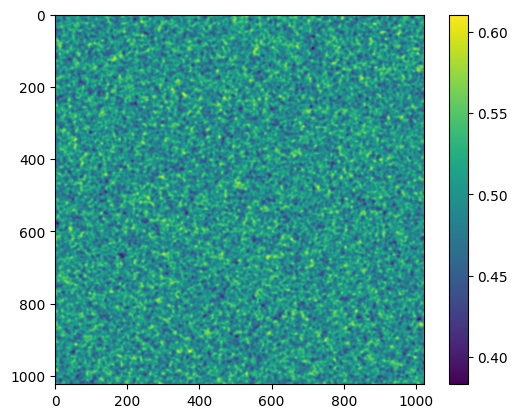

In [ ]:
# random flactuation noise generator:

img_size = 1024
mask_size = 32
rand_img_2D = np.random.rand(img_size + 2*mask_size, img_size + 2*mask_size)
# plt.imshow(rand_img_2D, cmap='viridis',vmax=1,vmin=0)
# plt.show()
tau = 10
range = mask_size//2
ticks = 1
x, y = np.mgrid[-range:range:ticks, -range:range:ticks]
# print(x.shape)
pos = np.dstack((x, y))
rv = sc.stats.multivariate_normal([0,0], [[tau, 0], [0, tau]])
mask = rv.pdf(pos)
# plt.imshow(mask, cmap='viridis',vmax=0.02,vmin=0)
# plt.colorbar()
# plt.show()


flactuation_img_2d = np.zeros((img_size, img_size))

for i in np.arange(mask_size,img_size + mask_size):
    for g in np.arange(mask_size,img_size + mask_size):
        section = rand_img_2D[i-mask_size//2:i+mask_size//2, g-mask_size//2:g+mask_size//2]
        flactuation_img_2d[i-mask_size,g-mask_size] = np.sum(section * mask)

plt.imshow(flactuation_img_2d, cmap='viridis')
# plt.xlim(0,50)
# plt.ylim(0,50)
plt.colorbar()
plt.show()


In [ ]:
# # genera circonferenza:
# Npoints = 100 
# radius = np.round(Npoints*1.2/(2*np.pi))
# center_x, center_y = (img_size//2, img_size//2)
# θ = np.linspace(0, 2*np.pi, Npoints)
# x_circle = np.round(center_x + radius * np.cos(θ))
# y_circle = np.round(center_y + radius * np.sin(θ))
# circle_coords = np.vstack((x_circle, y_circle)).astype(int).T

# # plt.imshow(flactuation_img_2d, cmap='viridis')
# # plt.scatter(circle_coords[:,0], circle_coords[:,1], color='red', s=1)

# random_values = flactuation_img_2d[circle_coords[:,1], circle_coords[:,0]]
# plt.plot(np.arange(Npoints), random_values, marker='o', markersize=3)
# plt.show()

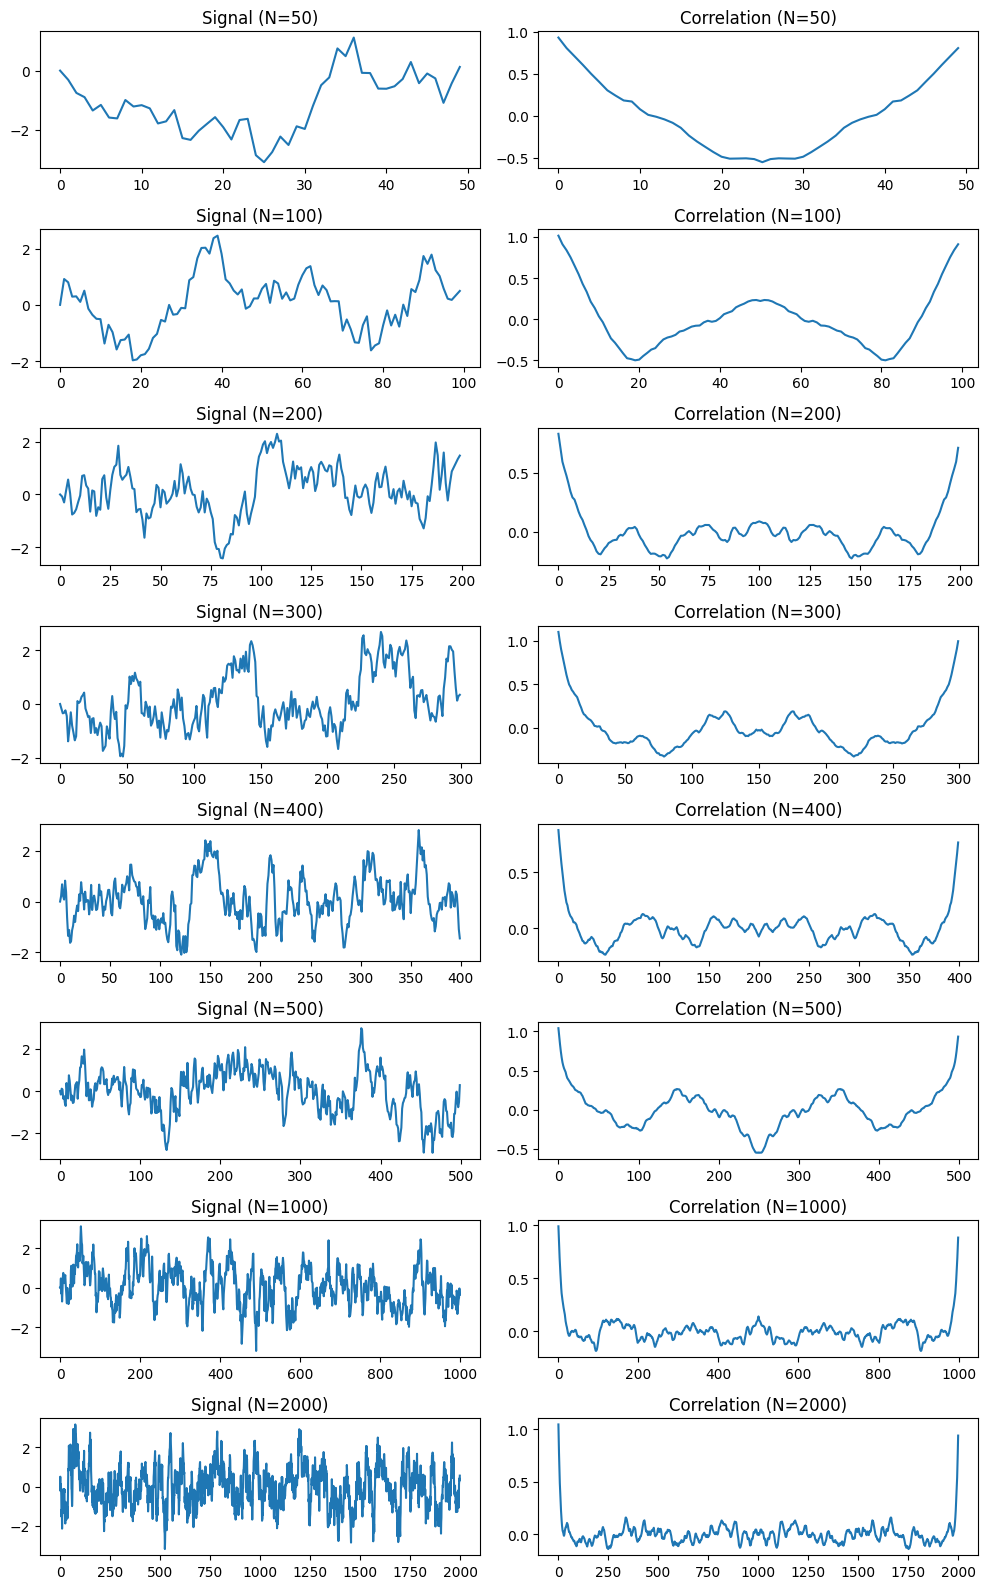

In [ ]:
def generate_random_flactuation(N):
    radius = np.round(N*1.2/(2*np.pi))
    center_x, center_y = (img_size//2, img_size//2)
    θ = np.linspace(0, 2*np.pi, N)
    x_circle = np.round(center_x + radius * np.cos(θ))
    y_circle = np.round(center_y + radius * np.sin(θ))
    circle_coords = np.vstack((x_circle, y_circle)).astype(int).T
    return flactuation_img_2d[circle_coords[:,1], circle_coords[:,0]]

def correlazione(signal):
    t = signal - np.mean(signal)
    fft_t = np.fft.fft(t)
    fft_t_c = np.conjugate(fft_t)
    crosscorr = np.real(np.fft.ifft(fft_t * fft_t_c))
    return crosscorr/len(signal)


def Ornstein_Uhlenbeck_process(N, tau):
    # Ornstein-Uhlenbeck process for characteristic time tau
    dt = 1.0
    signal = np.zeros(N)
    signal[0] = 0
    for i in np.arange(1, N):
        signal[i] = signal[i-1] + (-signal[i-1]/tau)*dt + np.sqrt(2*dt/tau)*np.random.normal()
    return signal


data = [Ornstein_Uhlenbeck_process(i,10.0) for i in [50,100,200,300,400,500,1000,2000]]
corre = [correlazione(i) for i in data]

fig, axs = plt.subplots(len(data), 2, figsize=(10, 2*len(data)))
for idx, i in enumerate(data):
    #x = np.arange(0, 1000, 1000/len(i))
    corr = corre[idx]
    axs[idx, 0].plot(i)
    axs[idx, 0].set_title(f'Signal (N={len(i)})')
    axs[idx, 1].plot(corr)
    axs[idx, 1].set_title(f'Correlation (N={len(i)})')
    # axs[idx, 1].set_xlim(0, 30)
    #axs[idx, 1].set_yscale('log')
plt.tight_layout()
    
plt.show()

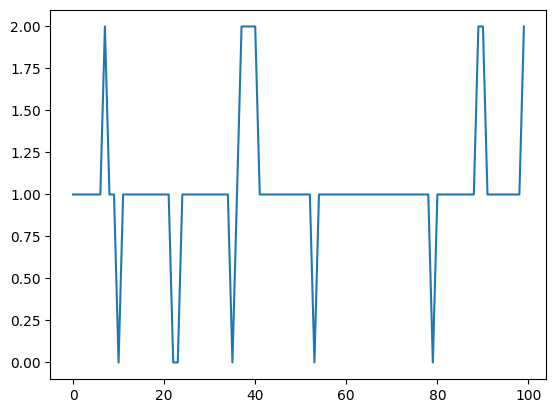

In [31]:
# real signal with low photon budget simulation
def real_Ornstein_Uhlenbeck_process(N, tau,photon_budget=100):
    # Ornstein-Uhlenbeck process for characteristic time tau
    signal = np.zeros(N)
    for i in np.arange(1, N):
        signal[i] = signal[i-1] + -signal[i-1]/tau + np.sqrt(2/tau)*np.random.normal()
    signal -= np.min(signal)
    signal /= np.sum(signal)
    signal *= photon_budget

    return np.round(signal)

plt.plot(real_Ornstein_Uhlenbeck_process(100,3,photon_budget=100))
plt.show()

0.3654319722143448 0.1445178550266266


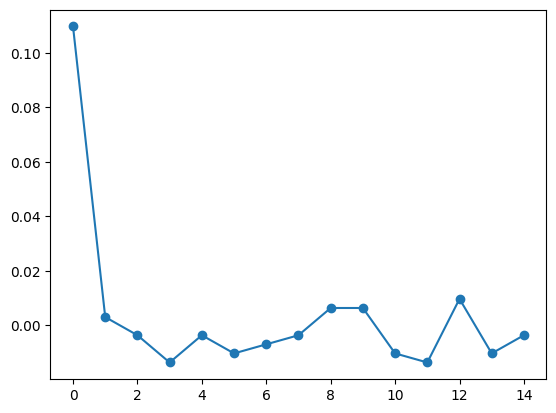

In [127]:
# #from scipy.stats import nanmean, nanstd

# N_datapoints = 30
# N_rep = 10
# PHB = 10 # photon budget

# tau = 1.0

# def exp_fit(x, tau, a, b):
#     return a * np.exp(-x / tau) + b

# def correlazione(signal):
#     t = signal - np.mean(signal)
#     fft_t = np.fft.fft(t)
#     fft_t_c = np.conjugate(fft_t)
#     crosscorr = np.real(np.fft.ifft(fft_t * fft_t_c))
#     return crosscorr/len(signal)

# data_100 = np.array([correlazione(real_Ornstein_Uhlenbeck_process(N_datapoints,tau,photon_budget=PHB))[:N_datapoints//2] for _ in np.arange(0,N_rep)])

# (t,_,_), pcov = sc.optimize.curve_fit(exp_fit, np.arange(N_datapoints//2), data_100.mean(axis=0), p0=(tau,data_100.mean(axis=0)[0],0.0), bounds=((0,0,-np.inf),(tau*10,np.inf,np.inf)))
# print(t, np.sqrt(np.diag(pcov))[0])

# plt.plot(data_100.mean(axis=0), marker='o')
# plt.show()
# # taus = np.zeros(N_test, dtype=np.float32)
# # for id,correlated_signal in enumerate(data_100):
# #     try:
# #         (taus[id],_,_), _ = sc.optimize.curve_fit(exp_fit, np.arange(N//2), correlated_signal, p0=(tau,correlated_signal[0],0.0), bounds=((0,0,-np.inf),(tau*10,np.inf,np.inf)))
# #         if taus[id] == tau*10:
# #             taus[id] = np.nan
# #     except Exception as e:
# #         taus[id] = np.nan
# # print(np.nanmean(taus), np.nanstd(taus),np.isnan(taus).sum())


In [ ]:
def correlazione(signal):
    t = signal - np.mean(signal)
    fft_t = np.fft.fft(t)
    fft_t_c = np.conjugate(fft_t)
    crosscorr = np.real(np.fft.ifft(fft_t * fft_t_c))
    return crosscorr/len(signal)


tau = 10
dt = 1
T = 100
N = int(T / dt)
t = np.arange(N) * dt

# Ornstein-Uhlenbeck process for characteristic time tau
signal = np.zeros(N)
signal[0] = 0
for i in range(1, N):
    signal[i] = signal[i-1] + (-signal[i-1]/tau)*dt + np.sqrt(2*dt/tau)*np.random.normal()

plt.plot(t, signal)
plt.show()
# Example usage:
# corr = correlazione(signal)

corr = correlazione(signal)
lags = np.arange(N) * dt
plt.plot(lags, corr)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

TypeError: 'int' object is not callable

tau_fit = 72.05289385538384


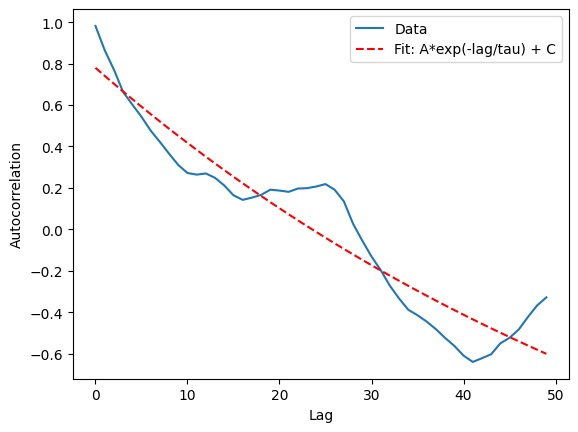

In [ ]:
def expofit(lags, A, tau, C):
    return A * np.exp(-lags/tau) + C

from scipy.optimize import curve_fit
popt, pcov = curve_fit(expofit, lags[:50], corr[:50], p0=(1, 1, 0))
A_fit, tau_fit, C_fit = popt
print('tau_fit =', tau_fit)

plt.plot(lags[:50], corr[:50], label='Data')
plt.plot(lags[:50], expofit(lags[:50], *popt), 'r--', label='Fit: A*exp(-lag/tau) + C')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.legend()
plt.show()